# Token Consumption Analysis

Analyze LangChain execution logs to identify which steps consume the most tokens.

Compatible with sample.json format and similar execution logs.

## Setup - Import Libraries

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Load and Parse the Log File

In [2]:
# Path to the log file - change this to analyze different logs
log_file = Path('../run.json')

# Load the JSON
with open(log_file, 'r') as f:
    data = json.load(f)

print(f"✓ Loaded {log_file}")
print(f"  Keys: {list(data.keys())}")

✓ Loaded ../run.json
  Keys: ['inputs', 'outputs', 'metadata', 'langsmith']


## Extract Token Consumption Data

In [3]:
def extract_token_data(data: dict) -> List[Dict]:
    """
    Extract token consumption from LangChain execution logs.
    
    Returns a list of dicts with token usage info per step.
    """
    steps = []
    messages = data.get('outputs', {}).get('messages', [])
    
    for idx, msg in enumerate(messages):
        msg_type = msg.get('type', 'unknown')
        
        # Get content preview
        content = msg.get('content', '')
        if isinstance(content, list):
            content_preview = str(content[0])[:100] if content else ''
        else:
            content_preview = str(content)[:100] if content else ''
        
        # Get token usage from response_metadata
        usage = msg.get('response_metadata', {}).get('usage', {})
        input_tokens = usage.get('input_tokens', 0)
        output_tokens = usage.get('output_tokens', 0)
        cache_read = usage.get('cache_read_input_tokens', 0)
        cache_creation = usage.get('cache_creation_input_tokens', 0)
        
        # Total tokens calculation
        total_tokens = input_tokens + output_tokens + cache_read + cache_creation
        
        # Check for tool calls
        has_tools = 'tool_calls' in msg or 'invalid_tool_calls' in msg
        
        steps.append({
            'step_index': idx,
            'message_type': msg_type,
            'content_preview': content_preview,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
            'cache_read_tokens': cache_read,
            'cache_creation_tokens': cache_creation,
            'total_tokens': total_tokens,
            'has_tool_calls': has_tools
        })
    
    return steps

# Extract data
steps = extract_token_data(data)
print(f"✓ Extracted {len(steps)} steps")

✓ Extracted 105 steps


## Create Token Summary Table

In [4]:
# Convert to DataFrame
df = pd.DataFrame(steps)

# Display basic stats
print("\n📊 TOKEN CONSUMPTION SUMMARY")
print("="*80)
print(f"\nTotal steps: {len(df)}")
print(f"Total input tokens: {df['input_tokens'].sum():,}")
print(f"Total output tokens: {df['output_tokens'].sum():,}")
print(f"Total cache read tokens: {df['cache_read_tokens'].sum():,}")
print(f"Total cache creation tokens: {df['cache_creation_tokens'].sum():,}")
print(f"TOTAL TOKENS: {df['total_tokens'].sum():,}")

print(f"\n\nBy Message Type:")
type_summary = df.groupby('message_type').agg({
    'total_tokens': ['sum', 'mean', 'count']
}).round(0)
print(type_summary)


📊 TOKEN CONSUMPTION SUMMARY

Total steps: 105
Total input tokens: 196
Total output tokens: 24,018
Total cache read tokens: 979,717
Total cache creation tokens: 41,743
TOTAL TOKENS: 1,045,674


By Message Type:
             total_tokens               
                      sum     mean count
message_type                            
ai                1045674  22732.0    46
human                   0      0.0     1
system                  0      0.0     1
tool                    0      0.0    57


## Top Token Consuming Steps

In [5]:
# Sort by total tokens and display top steps
top_steps = df.nlargest(10, 'total_tokens')[[
    'step_index', 'message_type', 'input_tokens', 'output_tokens', 
    'cache_read_tokens', 'cache_creation_tokens', 'total_tokens', 'has_tool_calls'
]].copy()

print("\n🔥 TOP 10 STEPS BY TOKEN CONSUMPTION")
print("="*100)
print(top_steps.to_string(index=False))

# Calculate percentages
total = df['total_tokens'].sum()
print("\n\n💡 PERCENTAGE OF TOTAL TOKENS:")
print("="*60)
top_10_pct = df.nlargest(10, 'total_tokens')['total_tokens'].sum() / total * 100
print(f"Top 10 steps: {top_10_pct:.1f}% of total tokens")
print(f"Top 5 steps: {df.nlargest(5, 'total_tokens')['total_tokens'].sum() / total * 100:.1f}% of total tokens")
print(f"Top 3 steps: {df.nlargest(3, 'total_tokens')['total_tokens'].sum() / total * 100:.1f}% of total tokens")


🔥 TOP 10 STEPS BY TOKEN CONSUMPTION
 step_index message_type  input_tokens  output_tokens  cache_read_tokens  cache_creation_tokens  total_tokens  has_tool_calls
        104           ai             3           1963              41416                    327         43709            True
        102           ai             4            181              40811                    605         41601            True
         99           ai             3            145              40517                    294         40959            True
         97           ai             3             82              37089                   3428         40602            True
         95           ai             4           3387              36565                    524         40480            True
         92           ai             3            194              33574                   2991         36762            True
         90           ai             3           2955              33328         

## Cache Effectiveness Analysis

In [6]:
# Cache analysis
cache_read = df['cache_read_tokens'].sum()
cache_creation = df['cache_creation_tokens'].sum()
fresh_input = df['input_tokens'].sum()
output = df['output_tokens'].sum()
total_all = cache_read + cache_creation + fresh_input + output

print("\n💾 CACHE EFFECTIVENESS")
print("="*60)
print(f"Fresh input tokens: {fresh_input:,} ({fresh_input/total_all*100:.1f}%)")
print(f"Output tokens: {output:,} ({output/total_all*100:.1f}%)")
print(f"Cache creation tokens: {cache_creation:,} ({cache_creation/total_all*100:.1f}%)")
print(f"Cache read tokens: {cache_read:,} ({cache_read/total_all*100:.1f}%)")
print("-" * 60)
print(f"TOTAL: {total_all:,}")

if cache_read > 0:
    savings = cache_read * 0.9
    print(f"\n✅ Cache savings: ~{savings:,.0f} tokens (90% discount on {cache_read:,})")
else:
    print(f"\n⚠️  No cache reads detected")


💾 CACHE EFFECTIVENESS
Fresh input tokens: 196 (0.0%)
Output tokens: 24,018 (2.3%)
Cache creation tokens: 41,743 (4.0%)
Cache read tokens: 979,717 (93.7%)
------------------------------------------------------------
TOTAL: 1,045,674

✅ Cache savings: ~881,745 tokens (90% discount on 979,717)


## Visualizations

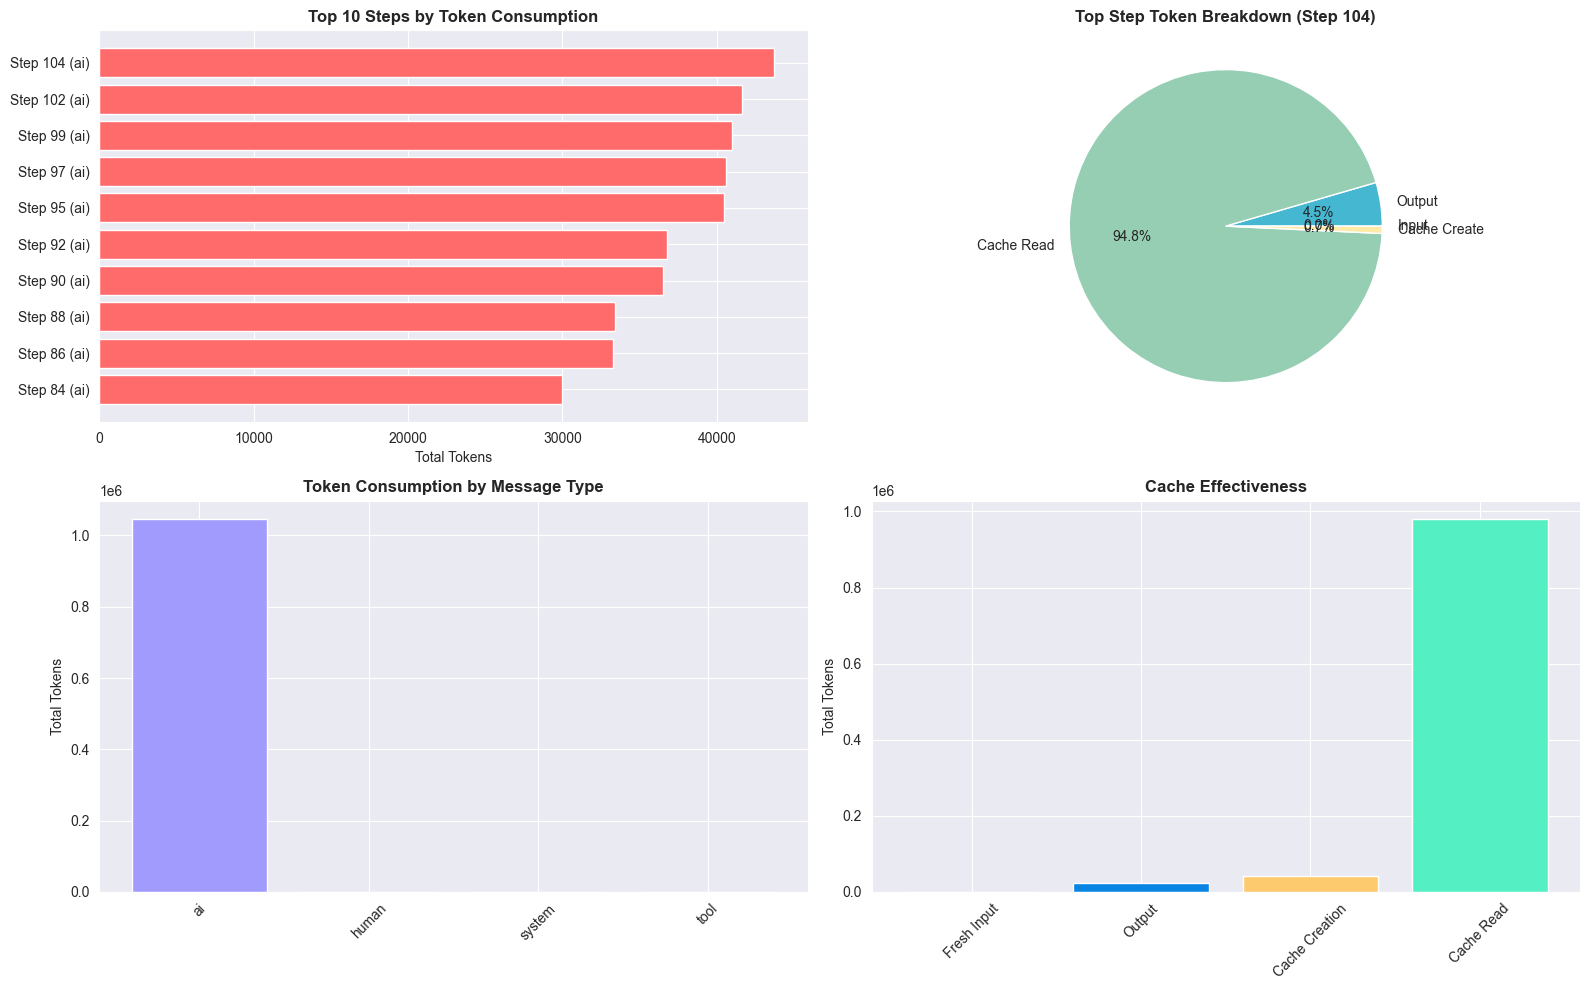

✓ Visualization saved to ../tmp/token_analysis.png


In [8]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 10 steps
top_10 = df.nlargest(10, 'total_tokens')
labels = [f"Step {int(row['step_index'])} ({row['message_type']})" for _, row in top_10.iterrows()]

axes[0, 0].barh(labels, top_10['total_tokens'], color='#FF6B6B')
axes[0, 0].set_xlabel('Total Tokens')
axes[0, 0].set_title('Top 10 Steps by Token Consumption', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()

# Token type breakdown for top step
top_step = df.nlargest(1, 'total_tokens').iloc[0]
token_types = {
    'Input': top_step['input_tokens'],
    'Output': top_step['output_tokens'],
    'Cache Read': top_step['cache_read_tokens'],
    'Cache Create': top_step['cache_creation_tokens']
}
token_types = {k: v for k, v in token_types.items() if v > 0}

colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[0, 1].pie(token_types.values(), labels=token_types.keys(), autopct='%1.1f%%', colors=colors[:len(token_types)])
axes[0, 1].set_title(f'Top Step Token Breakdown (Step {int(top_step["step_index"])})', fontweight='bold')

# Message type distribution
msg_type_tokens = df.groupby('message_type')['total_tokens'].sum().sort_values(ascending=False)
axes[1, 0].bar(msg_type_tokens.index, msg_type_tokens.values, color='#A29BFE')
axes[1, 0].set_ylabel('Total Tokens')
axes[1, 0].set_title('Token Consumption by Message Type', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Cache effectiveness
cache_data = {
    'Fresh Input': fresh_input,
    'Output': output,
    'Cache Creation': cache_creation,
    'Cache Read': cache_read
}
cache_data = {k: v for k, v in cache_data.items() if v > 0}

colors_cache = ['#FF7675', '#0984E3', '#FDCB6E', '#55EFC4']
axes[1, 1].bar(cache_data.keys(), cache_data.values(), color=colors_cache[:len(cache_data)])
axes[1, 1].set_ylabel('Total Tokens')
axes[1, 1].set_title('Cache Effectiveness', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../tmp/token_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to ../tmp/token_analysis.png")

## Tools and Generation Steps Analysis

Analyze which tools are called and their token consumption at each generation step.

In [9]:
def extract_tools_and_steps(data: dict) -> Tuple[pd.DataFrame, List[Dict]]:
    """
    Extract tool calls and generation steps with their token costs.
    Returns:
      - DataFrame with step-level details including tools called
      - List of tools called in order
    """
    messages = data.get('outputs', {}).get('messages', [])
    steps_with_tools = []
    tools_sequence = []
    
    for idx, msg in enumerate(messages):
        msg_type = msg.get('type', 'unknown')
        usage = msg.get('response_metadata', {}).get('usage', {})
        
        input_tokens = usage.get('input_tokens', 0)
        output_tokens = usage.get('output_tokens', 0)
        cache_read = usage.get('cache_read_input_tokens', 0)
        cache_creation = usage.get('cache_creation_input_tokens', 0)
        total_tokens = input_tokens + output_tokens + cache_read + cache_creation
        
        tools_called = []
        tool_calls = msg.get('tool_calls', [])
        
        if tool_calls:
            for tool_call in tool_calls:
                tool_name = tool_call.get('name', 'unknown')
                tools_called.append(tool_name)
                tools_sequence.append({
                    'step_index': idx,
                    'tool_name': tool_name,
                    'step_tokens': total_tokens
                })
        
        steps_with_tools.append({
            'step_index': idx,
            'message_type': msg_type,
            'tools_called': '|'.join(tools_called) if tools_called else 'none',
            'num_tools': len(tools_called),
            'total_tokens': total_tokens,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
            'cache_read_tokens': cache_read,
            'cache_creation_tokens': cache_creation
        })
    
    df_steps = pd.DataFrame(steps_with_tools)
    return df_steps, tools_sequence

# Extract data
df_steps, tools_seq = extract_tools_and_steps(data)
df_tools = pd.DataFrame(tools_seq) if tools_seq else pd.DataFrame()

print(f"✓ Extracted tools and generation steps")
print(f"  {len(df_steps)} total steps")
print(f"  {len(df_tools)} tool calls from {df_tools['tool_name'].nunique() if len(df_tools) > 0 else 0} unique tools")

✓ Extracted tools and generation steps
  105 total steps
  57 tool calls from 11 unique tools


## Tools by Consumption

In [10]:
print("\n🔧 TOOLS CALLED SUMMARY")
print("="*80)

if len(df_tools) > 0:
    tool_summary = df_tools.groupby('tool_name').agg({
        'step_index': 'count',
        'step_tokens': ['sum', 'mean']
    }).round(0)
    tool_summary.columns = ['Count', 'Total Tokens', 'Avg Tokens per Call']
    tool_summary = tool_summary.sort_values('Total Tokens', ascending=False)
    
    print("\nTools by Token Consumption:")
    print(tool_summary)
    
    print(f"\nTotal unique tools: {df_tools['tool_name'].nunique()}")
    print(f"Total tool invocations: {len(df_tools)}")
    
    print("\nTop 5 tools by invocation count:")
    tool_counts = df_tools['tool_name'].value_counts().head()
    for tool, count in tool_counts.items():
        print(f"  {tool}: {count} calls")
else:
    print("No tools called in this execution")


🔧 TOOLS CALLED SUMMARY

Tools by Token Consumption:
                       Count  Total Tokens  Avg Tokens per Call
tool_name                                                      
write_file                17        360529              21208.0
ls                        14        356106              25436.0
read_file                  8        201917              25240.0
write_todos                4         90785              22696.0
terraform_validate         4         64162              16040.0
glob                       2         59657              29828.0
review_and_fix_code        2         37162              18581.0
terraform_init             2         29212              14606.0
terraform_plan             1         18381              18381.0
search_knowledge_base      2         18342               9171.0
load_module_spec           1          9171               9171.0

Total unique tools: 11
Total tool invocations: 57

Top 5 tools by invocation count:
  write_file: 17 calls
  ls: 1

## Generation Sequence with Tools

In [11]:
print("\n📊 GENERATION SEQUENCE WITH TOOLS")
print("="*120)

ai_steps = df_steps[df_steps['message_type'] == 'ai'].copy()
print("\nAI Generation Steps (with tools called):")
for _, row in ai_steps.iterrows():
    tokens = f"{int(row['total_tokens']):,}"
    tools = row['tools_called'] if row['tools_called'] != 'none' else '-'
    print(f"  Step {int(row['step_index']):2d} | {tokens:>8} tokens | {tools}")

print(f"\n\n📈 TOKEN FLOW BY STEP TYPE")
print("="*80)
by_type = df_steps.groupby('message_type').agg({
    'total_tokens': ['sum', 'count', 'mean'],
    'num_tools': 'sum'
}).round(0)
by_type.columns = ['Total Tokens', 'Count', 'Avg Tokens', 'Total Tool Calls']
print(by_type)


📊 GENERATION SEQUENCE WITH TOOLS

AI Generation Steps (with tools called):
  Step  2 |    9,171 tokens | load_module_spec|search_knowledge_base|search_knowledge_base
  Step  6 |   11,792 tokens | write_todos
  Step  8 |   11,957 tokens | ls
  Step 10 |   12,178 tokens | write_file
  Step 12 |   12,513 tokens | write_file
  Step 14 |   12,772 tokens | write_file
  Step 16 |   13,030 tokens | write_file
  Step 18 |   13,255 tokens | write_file
  Step 20 |   13,590 tokens | write_file
  Step 22 |   13,849 tokens | write_file
  Step 24 |   14,107 tokens | write_file
  Step 26 |   14,326 tokens | write_todos
  Step 28 |   14,606 tokens | terraform_init|terraform_init
  Step 31 |   14,963 tokens | terraform_validate|terraform_validate
  Step 34 |   16,636 tokens | ls|ls
  Step 37 |   17,118 tokens | terraform_validate|terraform_validate
  Step 40 |   17,835 tokens | ls
  Step 42 |   17,953 tokens | ls
  Step 44 |   18,122 tokens | read_file
  Step 46 |   18,381 tokens | terraform_plan
  Ste

## Tool and Step Visualizations

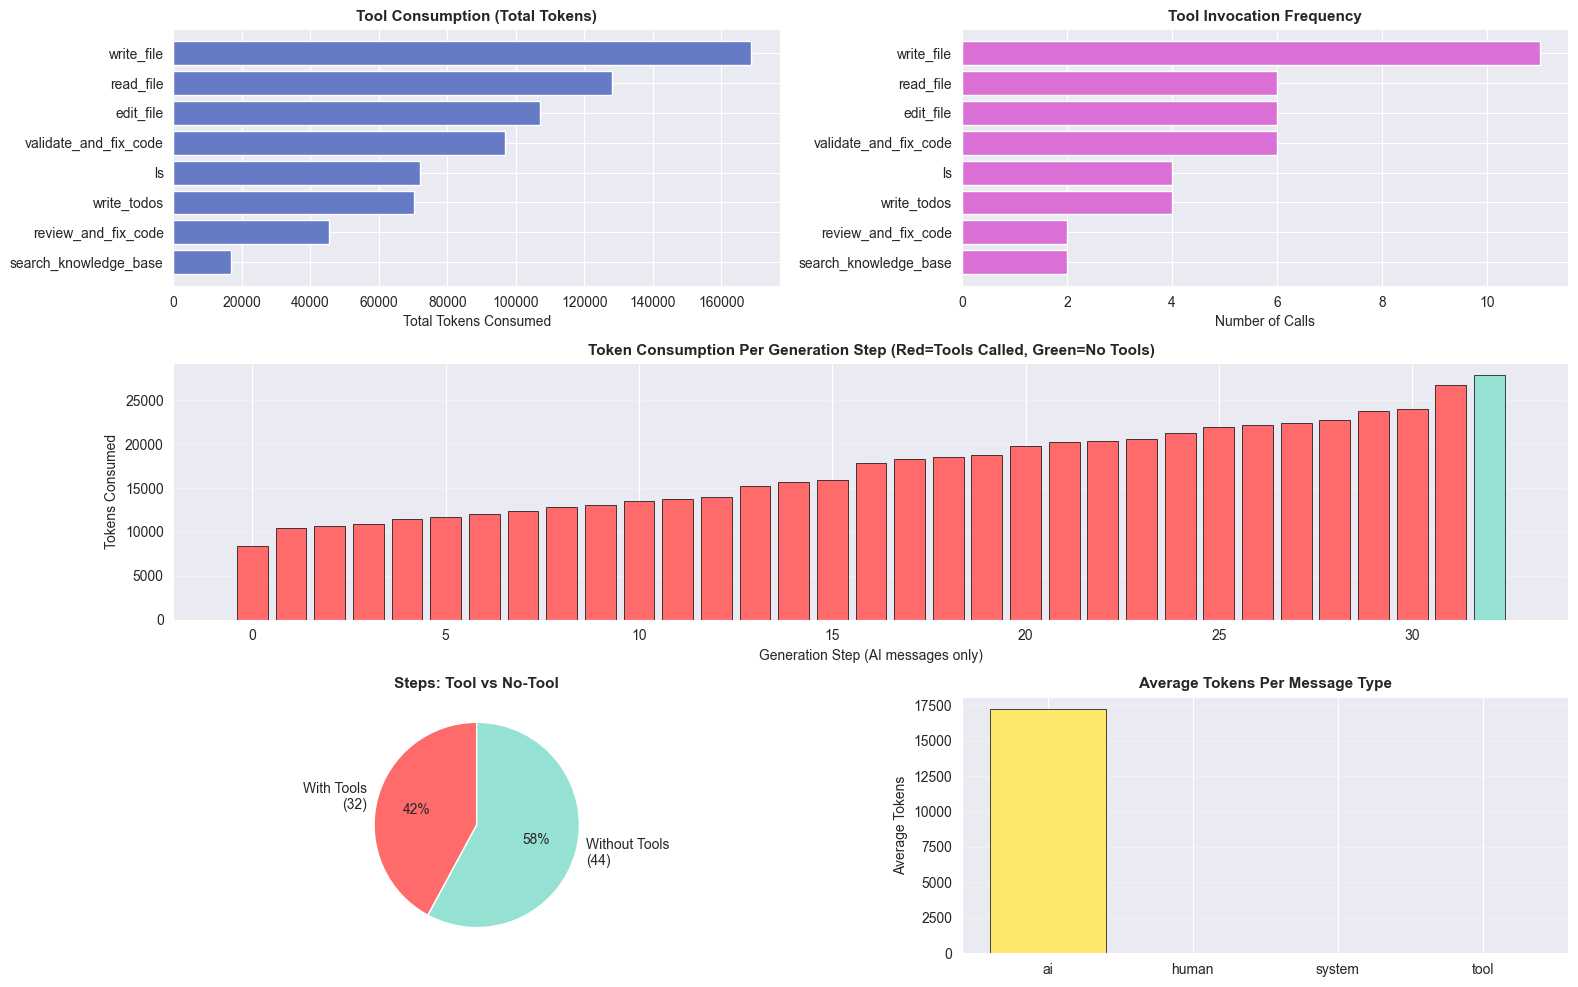


✓ Tool and generation visualizations saved to ../tmp/token_tools_analysis.png


In [33]:
if len(df_tools) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Tools by total consumption
    ax1 = fig.add_subplot(gs[0, 0])
    tool_totals = df_tools.groupby('tool_name')['step_tokens'].sum().sort_values(ascending=True)
    ax1.barh(tool_totals.index, tool_totals.values, color='#667BC6')
    ax1.set_xlabel('Total Tokens Consumed')
    ax1.set_title('Tool Consumption (Total Tokens)', fontweight='bold', fontsize=11)
    
    # 2. Tools by invocation count
    ax2 = fig.add_subplot(gs[0, 1])
    tool_counts = df_tools['tool_name'].value_counts().sort_values(ascending=True)
    ax2.barh(tool_counts.index, tool_counts.values, color='#DA70D6')
    ax2.set_xlabel('Number of Calls')
    ax2.set_title('Tool Invocation Frequency', fontweight='bold', fontsize=11)
    
    # 3. Generation step progression
    ax3 = fig.add_subplot(gs[1, :])
    ai_steps_seq = df_steps[df_steps['message_type'] == 'ai'].reset_index(drop=True)
    colors_seq = ['#FF6B6B' if row['num_tools'] > 0 else '#95E1D3' for _, row in ai_steps_seq.iterrows()]
    
    ax3.bar(range(len(ai_steps_seq)), ai_steps_seq['total_tokens'], color=colors_seq, edgecolor='black', linewidth=0.5)
    ax3.set_xlabel('Generation Step (AI messages only)')
    ax3.set_ylabel('Tokens Consumed')
    ax3.set_title('Token Consumption Per Generation Step (Red=Tools Called, Green=No Tools)', fontweight='bold', fontsize=11)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Distribution
    ax4 = fig.add_subplot(gs[2, 0])
    steps_with_tools = len(df_steps[df_steps['num_tools'] > 0])
    steps_without = len(df_steps[df_steps['num_tools'] == 0])
    
    values = [steps_with_tools, steps_without]
    labels = [f'With Tools\n({steps_with_tools})', f'Without Tools\n({steps_without})']
    colors_pie = ['#FF6B6B', '#95E1D3']
    
    ax4.pie(values, labels=labels, autopct='%1.0f%%', colors=colors_pie, startangle=90)
    ax4.set_title('Steps: Tool vs No-Tool', fontweight='bold', fontsize=11)
    
    # 5. Average per type
    ax5 = fig.add_subplot(gs[2, 1])
    type_avg = df_steps.groupby('message_type')['total_tokens'].mean().sort_values(ascending=False)
    ax5.bar(type_avg.index, type_avg.values, color='#FFE66D', edgecolor='black', linewidth=0.5)
    ax5.set_ylabel('Average Tokens')
    ax5.set_title('Average Tokens Per Message Type', fontweight='bold', fontsize=11)
    ax5.grid(axis='y', alpha=0.3)
    
    plt.savefig('../tmp/token_tools_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Tool and generation visualizations saved to ../tmp/token_tools_analysis.png")
else:
    print("No tools to visualize")

## Export Results

In [34]:
# Export token analysis
df_export = df[['step_index', 'message_type', 'input_tokens', 'output_tokens', 
                  'cache_read_tokens', 'cache_creation_tokens', 'total_tokens']].copy()
df_export.to_csv('../tmp/token_consumption_detailed.csv', index=False)
print("✓ Exported: token_consumption_detailed.csv")

# Export tool analysis
if len(df_tools) > 0:
    tool_summary = df_tools.groupby('tool_name').agg({
        'step_index': 'count',
        'step_tokens': ['sum', 'mean', 'min', 'max']
    }).round(0)
    tool_summary.columns = ['Invocations', 'Total Tokens', 'Avg Tokens', 'Min Tokens', 'Max Tokens']
    tool_summary = tool_summary.sort_values('Total Tokens', ascending=False)
    tool_summary.to_csv('../tmp/tool_consumption_by_tool.csv')
    print("✓ Exported: tool_consumption_by_tool.csv")

# Export generation steps with tool info
df_steps_export = df_steps[['step_index', 'message_type', 'tools_called', 'num_tools', 
                             'total_tokens', 'input_tokens', 'output_tokens', 
                             'cache_read_tokens', 'cache_creation_tokens']].copy()
df_steps_export.to_csv('../tmp/token_consumption_by_step.csv', index=False)
print("✓ Exported: token_consumption_by_step.csv")

print("\n✅ All analysis files exported to ../tmp/")

✓ Exported: token_consumption_detailed.csv
✓ Exported: tool_consumption_by_tool.csv
✓ Exported: token_consumption_by_step.csv

✅ All analysis files exported to ../tmp/


## Reusable Functions

In [35]:
def analyze_token_log(log_path: str) -> Tuple[pd.DataFrame, dict]:
    """Analyze a LangChain execution log and return token consumption data."""
    with open(log_path, 'r') as f:
        data = json.load(f)
    
    steps = extract_token_data(data)
    df = pd.DataFrame(steps)
    
    summary = {
        'total_steps': len(df),
        'total_tokens': int(df['total_tokens'].sum()),
        'total_input': int(df['input_tokens'].sum()),
        'total_output': int(df['output_tokens'].sum()),
        'avg_tokens_per_step': int(df['total_tokens'].mean()),
        'max_tokens_step': int(df['total_tokens'].max())
    }
    
    return df, summary

def print_token_summary(df: pd.DataFrame):
    """Print a formatted token summary."""
    print("\n📊 QUICK SUMMARY")
    print("="*60)
    print(f"Total steps: {len(df)}")
    print(f"Total tokens: {int(df['total_tokens'].sum()):,}")
    print(f"Average per step: {int(df['total_tokens'].mean()):,}")
    print(f"Max single step: {int(df['total_tokens'].max()):,}")
    print(f"\nTop 3 consuming steps:")
    for idx, row in df.nlargest(3, 'total_tokens').iterrows():
        print(f"  {int(row['step_index'])}. {row['message_type']}: {int(row['total_tokens']):,} tokens")